<a href="https://colab.research.google.com/github/a2w3r4/Basic-Neural-Network-using-Pytorch/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [109]:
# Create a Model Class that inherits nn.Module

In [110]:
class Model(nn.Module):
  # Input Layer (4 features of the flower)
  # --> Hidden_Layer1(number of neurons)
  #--> H2 (n)  --->
  # Output (3 classes of iris flowers)

 def __init__(self, input_features=4, h1=8, h2=9, output_features=3):
  super().__init__()    # instantiate our nn.Module
  self.fc1 = nn.Linear(input_features, h1)
  self.fc2 = nn.Linear(h1, h2)
  self.out = nn.Linear(h2, output_features)

 def forward(self, x):
   x = F.relu(self.fc1(x))
   x = F.relu(self.fc2(x))
   x = self.out(x)

   return x


In [111]:
# pick a manual seed for randomaization
torch.manual_seed(32)
# Create an instance of Model
model = Model()

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [113]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [114]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [115]:
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [116]:
my_df.tail()                                # last 5 rows

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [117]:
# Change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

/tmp/ipykernel_1628/169353329.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [118]:
# Train Test Split X, Y
X = my_df.drop('species', axis=1)
y = my_df['species']

In [119]:
#  Convert these to numpy arrays
X = X.values
y = y.values

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
# Train test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

In [122]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [123]:
# Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [124]:
# Set the criterion of model to measure the error, how far off the prediction are from
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = learning rate ( if our error doesn't go down after a bunch off iteration (epochs), lower our learning rate )
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [125]:
# Train our model
# epochs --> one run through all the training data in our data
epochs = 850
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train)  # Get predicted results

  #Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  #Keep Track of out losses
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch; {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thorugh the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch; 0 and loss: 1.169895887374878
Epoch; 10 and loss: 1.1307536363601685
Epoch; 20 and loss: 1.0943182706832886
Epoch; 30 and loss: 1.0664092302322388
Epoch; 40 and loss: 1.0409716367721558
Epoch; 50 and loss: 1.0179129838943481
Epoch; 60 and loss: 0.996281623840332
Epoch; 70 and loss: 0.9745318293571472
Epoch; 80 and loss: 0.9534372091293335
Epoch; 90 and loss: 0.9317707419395447
Epoch; 100 and loss: 0.9081366658210754
Epoch; 110 and loss: 0.8845569491386414
Epoch; 120 and loss: 0.8616767525672913
Epoch; 130 and loss: 0.8393822908401489
Epoch; 140 and loss: 0.8181856870651245
Epoch; 150 and loss: 0.7983383536338806
Epoch; 160 and loss: 0.7796430587768555
Epoch; 170 and loss: 0.762294590473175
Epoch; 180 and loss: 0.7462320923805237
Epoch; 190 and loss: 0.7309457659721375
Epoch; 200 and loss: 0.7156355977058411
Epoch; 210 and loss: 0.6866455078125
Epoch; 220 and loss: 0.6442301273345947
Epoch; 230 and loss: 0.5888983011245728
Epoch; 240 and loss: 0.5479819774627686
Epoch; 250 and lo

Text(0.5, 0, ' Epoch ')

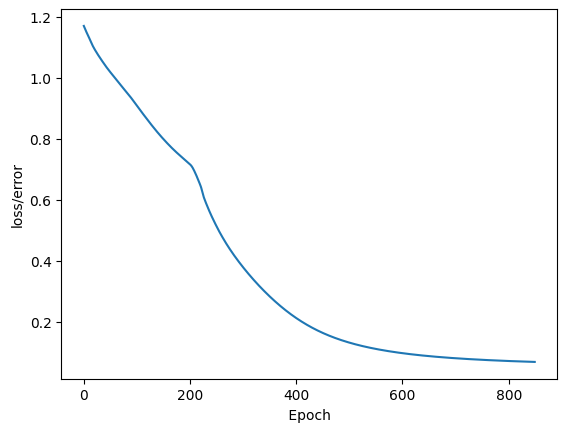

In [126]:
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel(' Epoch ')

 # We can change lr (learning-rate), epoch & random_state no.( mostly less) --> In order to increase the accuracy of the model and decrease the error in prediction

In [127]:
# Evaluate Model on Test Data Set (validate model on test set)

In [128]:
with torch.no_grad(): # Basically turnoff back-propagation
  y_eval = model.forward(X_test)    # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval, y_test)   # Find the loss or error
print(f"Test Loss: {loss.item()}")

Test Loss: 0.049407847225666046


In [129]:
loss

tensor(0.0494)

In [130]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    # will tell us What type of  flower class our network think it is
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    # Correct ot not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} correct!')

1.) tensor([-2.3927,  4.1678,  0.9026]) 	 1 	 1
2.) tensor([ 6.0569,  0.0299, -8.5423]) 	 0 	 0
3.) tensor([ 5.3153,  0.2901, -7.6772]) 	 0 	 0
4.) tensor([-2.3060,  4.4951,  0.6815]) 	 1 	 1
5.) tensor([-5.7850,  2.2650,  5.0239]) 	 2 	 2
6.) tensor([-5.6959,  3.3608,  4.5091]) 	 2 	 2
7.) tensor([ 4.8265,  0.6565, -7.1455]) 	 0 	 0
8.) tensor([ 5.5015,  0.1864, -7.8697]) 	 0 	 0
9.) tensor([-1.7603,  4.5487,  0.1079]) 	 1 	 1
10.) tensor([ 5.8716,  0.0227, -8.2756]) 	 0 	 0
11.) tensor([-2.7272,  4.9367,  0.9624]) 	 1 	 1
12.) tensor([-6.5768,  1.4219,  6.0838]) 	 2 	 2
13.) tensor([-1.2802,  4.5479, -0.3595]) 	 1 	 1
14.) tensor([-0.6489,  4.9176, -1.2278]) 	 1 	 1
15.) tensor([-5.6561,  2.3383,  4.8363]) 	 2 	 2
16.) tensor([-6.6180,  1.0591,  6.2155]) 	 2 	 2
17.) tensor([-2.6923,  3.7163,  1.3580]) 	 1 	 1
18.) tensor([-5.0585,  2.7431,  4.0952]) 	 2 	 2
19.) tensor([-1.0128,  4.8720, -0.7759]) 	 1 	 1
20.) tensor([ 6.2653,  0.0381, -8.8423]) 	 0 	 0
21.) tensor([ 5.5295,  0.2656

In [131]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
     x = "Setosa"
    elif y_test[i] == 1:
      x = "Versicolor"
    else:
      x = "Virginica"

    # will tell us What type of  flower class our network think it is
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    # Correct ot not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} correct!')

1.) tensor([-2.3927,  4.1678,  0.9026]) 	 1 	 1
2.) tensor([ 6.0569,  0.0299, -8.5423]) 	 0 	 0
3.) tensor([ 5.3153,  0.2901, -7.6772]) 	 0 	 0
4.) tensor([-2.3060,  4.4951,  0.6815]) 	 1 	 1
5.) tensor([-5.7850,  2.2650,  5.0239]) 	 2 	 2
6.) tensor([-5.6959,  3.3608,  4.5091]) 	 2 	 2
7.) tensor([ 4.8265,  0.6565, -7.1455]) 	 0 	 0
8.) tensor([ 5.5015,  0.1864, -7.8697]) 	 0 	 0
9.) tensor([-1.7603,  4.5487,  0.1079]) 	 1 	 1
10.) tensor([ 5.8716,  0.0227, -8.2756]) 	 0 	 0
11.) tensor([-2.7272,  4.9367,  0.9624]) 	 1 	 1
12.) tensor([-6.5768,  1.4219,  6.0838]) 	 2 	 2
13.) tensor([-1.2802,  4.5479, -0.3595]) 	 1 	 1
14.) tensor([-0.6489,  4.9176, -1.2278]) 	 1 	 1
15.) tensor([-5.6561,  2.3383,  4.8363]) 	 2 	 2
16.) tensor([-6.6180,  1.0591,  6.2155]) 	 2 	 2
17.) tensor([-2.6923,  3.7163,  1.3580]) 	 1 	 1
18.) tensor([-5.0585,  2.7431,  4.0952]) 	 2 	 2
19.) tensor([-1.0128,  4.8720, -0.7759]) 	 1 	 1
20.) tensor([ 6.2653,  0.0381, -8.8423]) 	 0 	 0
21.) tensor([ 5.5295,  0.2656

# Evaluate new data on the Neural Network

Testing A new kind of flower with different sepal_length, sepal_width, petal_length, petal_width [features] which is not in our training dataset

In [132]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [135]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 5.6026,  0.0121, -7.8883])


In [136]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [137]:
with torch.no_grad():
  print(model(newer_iris))

tensor([-5.1052,  2.2314,  4.3248])


# Save our Neural Network *Model*

In [139]:
torch.save(model.state_dict(), 'my_really_awesome_iris_model.pt')

In [140]:
#Load the Saved Model

new_model = Model()
new_model.load_state_dict(torch.load('my_really_awesome_iris_model.pt'))


<All keys matched successfully>

In [ ]:
# Make sure it loaded corretly

In [142]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)